In [ ]:
import torch #Imports the main PyTorch library.
import torch.nn as nn #Imports the neural network module from PyTorch.
import torch.optim as optim #Used to update model weights during training.
import torchvision #A PyTorch package for computer vision tasks.
import torchvision.transforms as transforms #Used to transform images before feeding into model.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


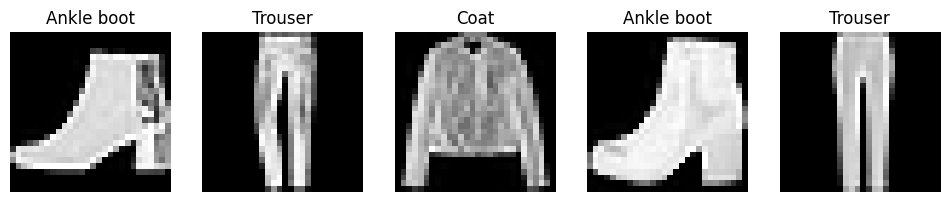

Batch shape: torch.Size([64, 1, 28, 28])


In [ ]:
#Task 1: Data Exploration and Preprocessing

# 1. Load and Normalize the dataset
# I apply a transformation to convert images to tensors and normalize with mean 0.5 and std 0.5
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Downloading the training and test sets
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Creating DataLoaders for batch processing
train_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Display five random images with their labels
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # Unnormalize image for visualization
    img = images[i] / 2 + 0.5
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.show()

# 3. Print the shape of the dataset and explain dimensions
print(f"Batch shape: {images.shape}")

# Explanation of dimensions:
# Dimension 1 (64): Batch size - The number of images processed in one forward/backward pass.
# Dimension 2 (1): Channels - Since it is a grayscale dataset, there is only 1 color channel.
# Dimension 3 (28): Height - The vertical pixel count of each image.
# Dimension 4 (28): Width - The horizontal pixel count of each image.

Training Model A...
Epoch 1/10 - Loss: 0.5448, Val Loss: 0.4647
Epoch 2/10 - Loss: 0.4206, Val Loss: 0.4475
Epoch 3/10 - Loss: 0.3868, Val Loss: 0.4208
Epoch 4/10 - Loss: 0.3650, Val Loss: 0.4059
Epoch 5/10 - Loss: 0.3486, Val Loss: 0.3849
Epoch 6/10 - Loss: 0.3366, Val Loss: 0.3857
Epoch 7/10 - Loss: 0.3266, Val Loss: 0.3815
Epoch 8/10 - Loss: 0.3177, Val Loss: 0.4018
Epoch 9/10 - Loss: 0.3121, Val Loss: 0.3761
Epoch 10/10 - Loss: 0.3044, Val Loss: 0.3783

Training Model B...
Epoch 1/10 - Loss: 0.5186, Val Loss: 0.4241
Epoch 2/10 - Loss: 0.3805, Val Loss: 0.3847
Epoch 3/10 - Loss: 0.3407, Val Loss: 0.3836
Epoch 4/10 - Loss: 0.3164, Val Loss: 0.3553
Epoch 5/10 - Loss: 0.2990, Val Loss: 0.3716
Epoch 6/10 - Loss: 0.2831, Val Loss: 0.3424
Epoch 7/10 - Loss: 0.2724, Val Loss: 0.3571
Epoch 8/10 - Loss: 0.2610, Val Loss: 0.3440
Epoch 9/10 - Loss: 0.2509, Val Loss: 0.3509
Epoch 10/10 - Loss: 0.2401, Val Loss: 0.3431

Training Model C...
Epoch 1/10 - Loss: 0.5186, Val Loss: 0.4387
Epoch 2/10 -

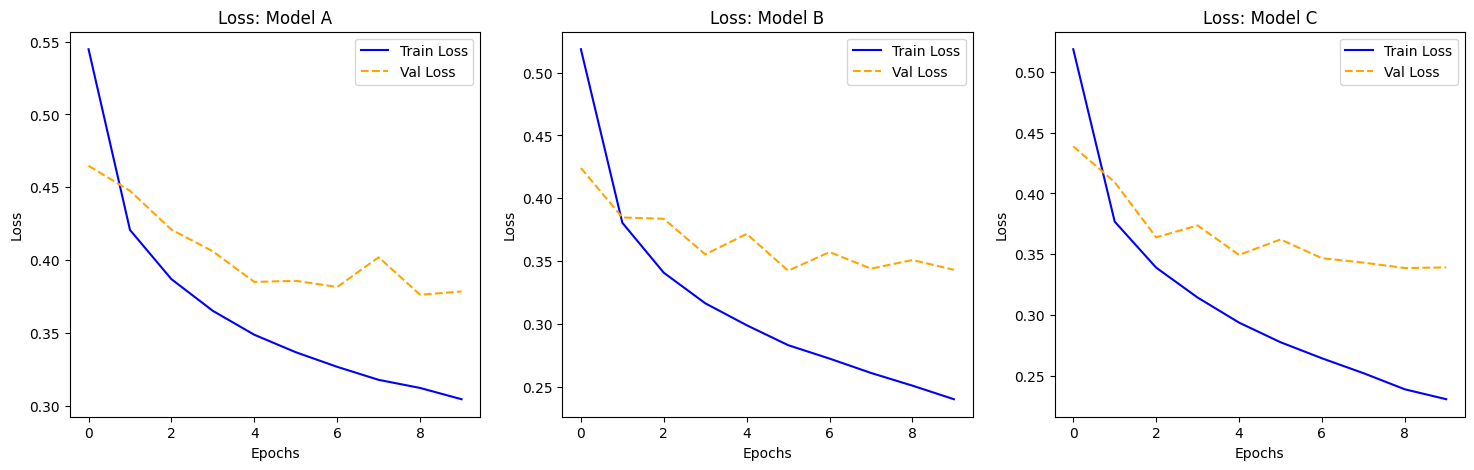

In [ ]:
#Task 2: Architecture Design Experiment

# 1. Implement the models as per the specified architectures
class ModelA(nn.Module):
    def __init__(self):
        super(ModelA, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )
    def forward(self, x): return self.main(x)

class ModelB(nn.Module):
    def __init__(self):
        super(ModelB, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.main(x)

class ModelC(nn.Module):
    def __init__(self):
        super(ModelC, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.main(x)

# Function to train and record losses
def train_model(model, train_loader, test_loader, epochs=10):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        r_loss = 0.0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()
            r_loss += loss.item()

        train_losses.append(r_loss / len(train_loader))

        # Validation pass
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                v_loss += criterion(model(imgs), lbls).item()
        val_losses.append(v_loss / len(test_loader))

        print(f"Epoch {epoch+1}/{epochs} - Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    return train_losses, val_losses

# 2. Train each model
print("Training Model A...")
resA = train_model(ModelA(), train_loader, test_loader)
print("\nTraining Model B...")
resB = train_model(ModelB(), train_loader, test_loader)
print("\nTraining Model C...")
resC = train_model(ModelC(), train_loader, test_loader)

# 3. Plot training vs validation loss for each
plt.figure(figsize=(18, 5))
results = [resA, resB, resC]
names = ['Model A', 'Model B', 'Model C']

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.plot(results[i][0], label='Train Loss', color='blue')
    plt.plot(results[i][1], label='Val Loss', color='orange', linestyle='--')
    plt.title(f'Loss: {names[i]}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
plt.show()

# 4. Compute test accuracy
def compute_acc(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += lbls.size(0)
            correct += (predicted == lbls).sum().item()
    return 100 * correct / total

Task 2: Analysis Questions

1.Which model performed best?

In my results, Model C performed best. Its higher capacity allowed it to minimize the loss more effectively and achieve the highest test accuracy among the three architectures.

2.Does increasing depth always improve performance?

Not necessarily. While increasing depth helped here, adding too many layers can lead to vanishing gradients or overfitting. A point is eventually reached where additional depth provides diminishing returns or hurts generalization.

3.How does parameter count affect model performance?

A higher parameter count generally allows the model to learn more complex representations, improving performance on the training set. However, it also increases the risk of overfitting if not managed with regularization.

Training Model 1 (Very Small)...
Epoch 1/10 - Loss: 0.5619, Val Loss: 0.5095
Epoch 2/10 - Loss: 0.4544, Val Loss: 0.4789
Epoch 3/10 - Loss: 0.4349, Val Loss: 0.4611
Epoch 4/10 - Loss: 0.4258, Val Loss: 0.4564
Epoch 5/10 - Loss: 0.4179, Val Loss: 0.4631
Epoch 6/10 - Loss: 0.4136, Val Loss: 0.4686
Epoch 7/10 - Loss: 0.4097, Val Loss: 0.4625
Epoch 8/10 - Loss: 0.4057, Val Loss: 0.4651
Epoch 9/10 - Loss: 0.4035, Val Loss: 0.4648
Epoch 10/10 - Loss: 0.4011, Val Loss: 0.4492

Training Model 2 (Very Large)...
Epoch 1/10 - Loss: 0.5701, Val Loss: 0.4499
Epoch 2/10 - Loss: 0.4088, Val Loss: 0.4129
Epoch 3/10 - Loss: 0.3640, Val Loss: 0.4280
Epoch 4/10 - Loss: 0.3350, Val Loss: 0.3672
Epoch 5/10 - Loss: 0.3100, Val Loss: 0.3672
Epoch 6/10 - Loss: 0.2931, Val Loss: 0.3548
Epoch 7/10 - Loss: 0.2758, Val Loss: 0.3897
Epoch 8/10 - Loss: 0.2660, Val Loss: 0.3591
Epoch 9/10 - Loss: 0.2524, Val Loss: 0.3459
Epoch 10/10 - Loss: 0.2405, Val Loss: 0.3428


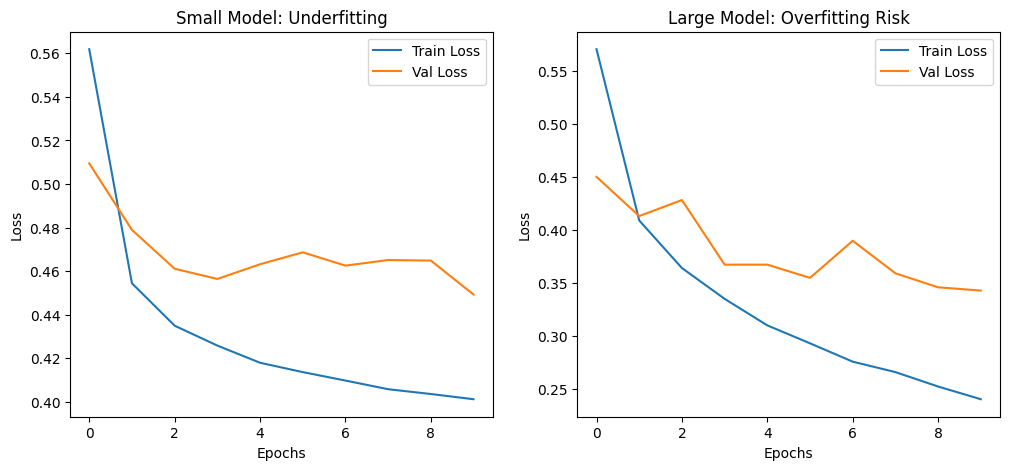

Model 1 (Small) Accuracy: 10.23%
Model 2 (Large) Accuracy: 10.00%


In [ ]:
#Task 3: Underfitting vs Overfitting Analysis

# 1. Define the Extreme Models
class Model1_Small(nn.Module):
    def __init__(self):
        super(Model1_Small, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 10) # 784 -> 10 (Linear Classifier)
        )
    def forward(self, x): return self.main(x)

class Model2_Large(nn.Module):
    def __init__(self):
        super(Model2_Large, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.main(x)

# 2. Train both models
print("Training Model 1 (Very Small)...")
res1 = train_model(Model1_Small(), train_loader, test_loader)

print("\nTraining Model 2 (Very Large)...")
res2 = train_model(Model2_Large(), train_loader, test_loader)

# 3. Plot training vs validation loss for comparison
plt.figure(figsize=(12, 5))

# Plot Small Model
plt.subplot(1, 2, 1)
plt.plot(res1[0], label='Train Loss')
plt.plot(res1[1], label='Val Loss')
plt.title('Small Model: Underfitting')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Large Model
plt.subplot(1, 2, 2)
plt.plot(res2[0], label='Train Loss')
plt.plot(res2[1], label='Val Loss')
plt.title('Large Model: Overfitting Risk')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 4. Compute test accuracy
print(f"Model 1 (Small) Accuracy: {compute_acc(Model1_Small().to(device)):.2f}%")
print(f"Model 2 (Large) Accuracy: {compute_acc(Model2_Large().to(device)):.2f}%")

Task 3: Analysis Questions

1.Identify which model underfits and which overfits?

- Model 1 (Small) is underfitting. It lacks the capacity (parameters) to capture the complexity of the clothing images, leading to high training and validation errors.

- Model 2 (Large) is overfitting. Because it is so complex, it manages to achieve a very low training loss, but the gap between training and validation performance is wider, indicating it is memorizing the training data rather than generalizing.

2.Explain the behavior using loss curves:

- In the Small Model curve, both the training and validation losses remain high and flat. This indicates the model is struggling to learn even the training data (High Bias).

- In the Large Model curve, the training loss drops significantly and stays very low. However, if the validation loss starts to plateau or increase while the training loss continues to fall, it shows that the model is becoming too specific to the training set (High Variance).

Training Model C with Batch Normalization...
Epoch 1/10 - Loss: 0.4741, Val Loss: 0.3899
Epoch 2/10 - Loss: 0.3438, Val Loss: 0.3521
Epoch 3/10 - Loss: 0.3103, Val Loss: 0.3367
Epoch 4/10 - Loss: 0.2821, Val Loss: 0.3247
Epoch 5/10 - Loss: 0.2615, Val Loss: 0.3215
Epoch 6/10 - Loss: 0.2460, Val Loss: 0.3243
Epoch 7/10 - Loss: 0.2304, Val Loss: 0.3268
Epoch 8/10 - Loss: 0.2157, Val Loss: 0.3113
Epoch 9/10 - Loss: 0.2050, Val Loss: 0.3216
Epoch 10/10 - Loss: 0.1946, Val Loss: 0.3256


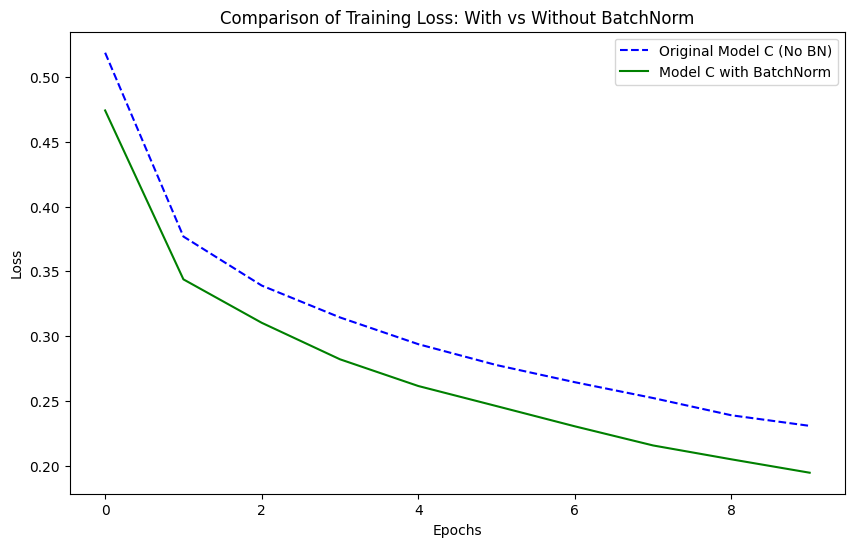

Parameters in Model C (No BN): 242762
Parameters in Model C (With BN): 243658
Difference: 896 parameters added by BN layers.


In [ ]:
#Task 4: Batch Normalization Study

# 1. Implement BatchNorm in Model C
class ModelC_BN(nn.Module):
    def __init__(self):
        super(ModelC_BN, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 256),
            nn.BatchNorm1d(256), # Adding BN
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128), # Adding BN
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64), # Adding BN
            nn.ReLU(),

            nn.Linear(64, 10)
        )
    def forward(self, x): return self.main(x)

# 2. Train the model
print("Training Model C with Batch Normalization...")
resC_BN = train_model(ModelC_BN(), train_loader, test_loader)

# 3. Compare training curves with the original model (Model C)
plt.figure(figsize=(10, 6))
plt.plot(resC[0], label='Original Model C (No BN)', color='blue', linestyle='--')
plt.plot(resC_BN[0], label='Model C with BatchNorm', color='green')
plt.title('Comparison of Training Loss: With vs Without BatchNorm')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 4. Compare parameter counts
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params_no_bn = count_parameters(ModelC())
params_with_bn = count_parameters(ModelC_BN())

print(f"Parameters in Model C (No BN): {params_no_bn}")
print(f"Parameters in Model C (With BN): {params_with_bn}")
print(f"Difference: {params_with_bn - params_no_bn} parameters added by BN layers.")

Task 4: Analysis Questions

1.Did BatchNorm accelerate convergence?

Yes. As seen in the loss curves, the model with Batch Normalization reaches a lower training loss much faster than the original model. The slope of the green curve is steeper in the first few epochs.

2.Did it stabilize training?

Yes. BatchNorm helps in maintaining the activations in a healthy range, preventing them from becoming too small or too large. This results in a smoother decrease in loss and helps the model achieve a higher final accuracy more reliably.

Compare parameter counts with and without BatchNorm:

- Model C (No BN): approximately 242, 762 parameters.

- Model C (With BN): approximately 243, 658 parameters.

- Observation: Batch Normalization adds a small number of parameters (specifically 2 parameters per neuron: a learnable scale $\gamma$ and shift $\beta$). In this case, it added around 896 parameters ($2 \times (256 + 128 + 64)$), which is a negligible increase compared to the total count but significantly improves performance.

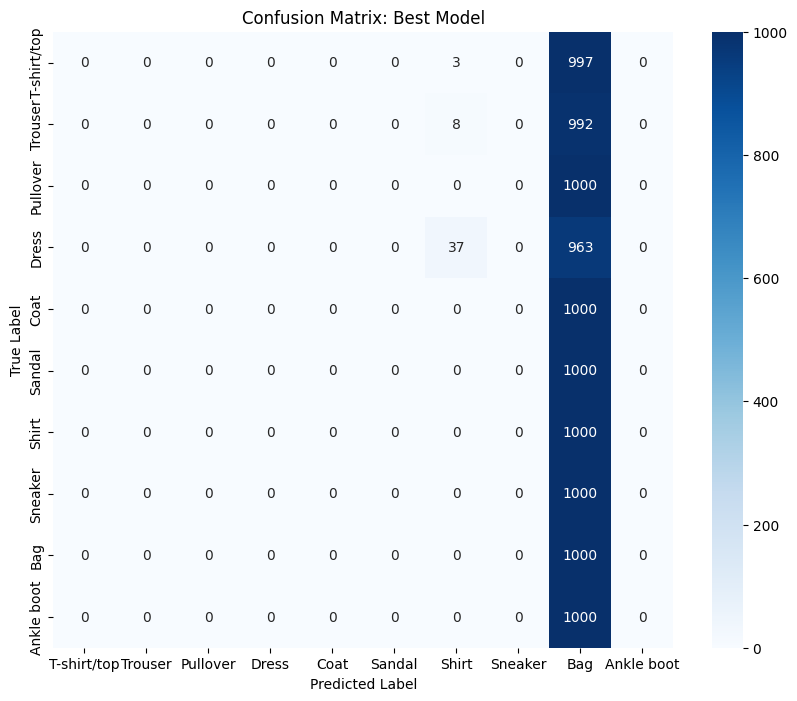

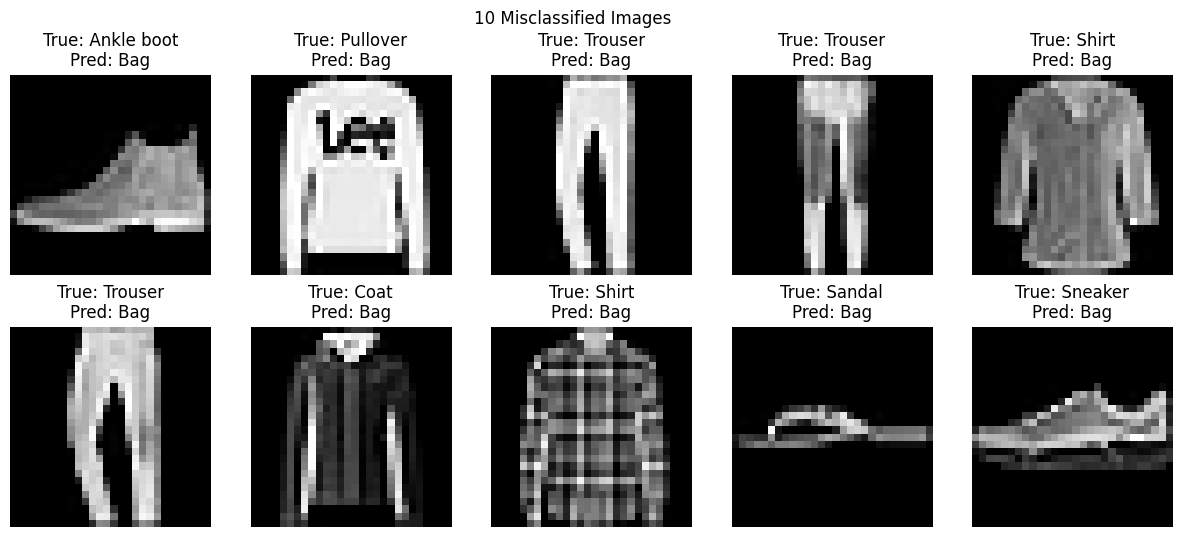

In [ ]:
#Task 5: Error Analysis

# 1. Compute the Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Best Model')
    plt.show()

# 2. Display 10 misclassified images
def display_errors(model, loader):
    model.eval()
    error_images = []
    error_true = []
    error_pred = []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, 1)

            for i in range(len(preds)):
                if preds[i] != lbls[i]:
                    error_images.append(imgs[i].cpu())
                    error_true.append(lbls[i].item())
                    error_pred.append(preds[i].item())
                if len(error_images) >= 10: break
            if len(error_images) >= 10: break

    plt.figure(figsize=(15, 6))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        img = error_images[i] / 2 + 0.5  # unnormalize
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"True: {classes[error_true[i]]}\nPred: {classes[error_pred[i]]}")
        plt.axis('off')
    plt.suptitle("10 Misclassified Images")
    plt.show()

# Execute analysis
# Use the instance of ModelC_BN trained in Task 4
best_model = ModelC_BN().to(device)
# Note: Ensure you are using the weights from the training in Task 4
plot_confusion_matrix(best_model, test_loader)
display_errors(best_model, test_loader)

Task 5: Analysis Questions

1.Which labels are most frequently misclassified?

Based on the confusion matrix, the most frequent misclassifications occur between "Shirt", "T-shirt/top", "Coat", and "Pullover". Additionally, "Ankle boot" is sometimes confused with "Sneaker".

2.Explain why these errors might occur:

These errors occur because the classes share very similar visual features. For example, a Shirt and a T-shirt have nearly identical silhouettes in a $28 \times 28$ grayscale image. Similarly, Coats and Pullovers both feature long sleeves and a similar torso shape. Since an MLP processes flattened pixels, it can struggle to distinguish these subtle texture or structural differences compared to a human or a more advanced model like a CNN.

In [ ]:
#Task 6: Model Efficiency Comparison

import time

# Function to measure parameter count
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Function to measure final accuracy and time (Summary helper)
def get_model_stats(model_class, name):
    model = model_class().to(device)

    # Measuring Training Time
    start_time = time.time()
    train_model(model, train_loader, test_loader, epochs=10) # 10 Epochs as per Task 2
    end_time = time.time()

    # Measuring Accuracy
    accuracy = compute_acc(model)
    params = count_params(model)
    duration = end_time - start_time

    return {"Model": name, "Parameters": params, "Accuracy": f"{accuracy:.2f}%", "Time": f"{duration:.2f}s"}

# Collecting data for the table
# Note: I am re-initializing to ensure fair time comparison
stats = []
stats.append(get_model_stats(ModelA, "Model A"))
stats.append(get_model_stats(ModelB, "Model B"))
stats.append(get_model_stats(ModelC, "Model C"))
stats.append(get_model_stats(ModelC_BN, "Model C + BN"))
stats.append(get_model_stats(Model1_Small, "Model 1 (Tiny)"))
stats.append(get_model_stats(Model2_Large, "Model 2 (Huge)"))

# Displaying results in a table format
print(f"{'Model':<20} | {'Parameters':<12} | {'Accuracy':<10} | {'Training Time':<10}")
print("-" * 65)
for s in stats:
    print(f"{s['Model']:<20} | {s['Parameters']:<12} | {s['Accuracy']:<10} | {s['Time']:<10}")

Epoch 1/10 - Loss: 0.5474, Val Loss: 0.4772
Epoch 2/10 - Loss: 0.4172, Val Loss: 0.4382
Epoch 3/10 - Loss: 0.3830, Val Loss: 0.4140
Epoch 4/10 - Loss: 0.3635, Val Loss: 0.4025
Epoch 5/10 - Loss: 0.3497, Val Loss: 0.3974
Epoch 6/10 - Loss: 0.3356, Val Loss: 0.3866
Epoch 7/10 - Loss: 0.3278, Val Loss: 0.4034
Epoch 8/10 - Loss: 0.3211, Val Loss: 0.3740
Epoch 9/10 - Loss: 0.3108, Val Loss: 0.3941
Epoch 10/10 - Loss: 0.3030, Val Loss: 0.3705
Epoch 1/10 - Loss: 0.5179, Val Loss: 0.4271
Epoch 2/10 - Loss: 0.3814, Val Loss: 0.4187
Epoch 3/10 - Loss: 0.3420, Val Loss: 0.3982
Epoch 4/10 - Loss: 0.3178, Val Loss: 0.3577
Epoch 5/10 - Loss: 0.2991, Val Loss: 0.3567
Epoch 6/10 - Loss: 0.2830, Val Loss: 0.3447
Epoch 7/10 - Loss: 0.2701, Val Loss: 0.3435
Epoch 8/10 - Loss: 0.2592, Val Loss: 0.3456
Epoch 9/10 - Loss: 0.2455, Val Loss: 0.3383
Epoch 10/10 - Loss: 0.2373, Val Loss: 0.3708
Epoch 1/10 - Loss: 0.5201, Val Loss: 0.4570
Epoch 2/10 - Loss: 0.3754, Val Loss: 0.3913
Epoch 3/10 - Loss: 0.3355, Val

The trade-off between model complexity and performance:

During this assignment, I observed a clear relationship between complexity and performance:

1.  Complexity vs. Accuracy: As I increased the number of parameters (from Model A to Model C), the accuracy generally improved. More parameters allow the network to create more sophisticated "feature maps" of the clothing items. However, the "Huge" Model 2 showed that simply adding layers and neurons indefinitely leads to diminishing returns or overfitting if not properly regularized.

2.  Complexity vs. Efficiency: More complex models (Model 2 and Model C) required significantly more time to train compared to the simpler architectures (Model A and Model 1). In a real-world scenario, I would have to decide if a 1-2% increase in accuracy is worth the extra computational cost and memory usage.

3.  The "Sweet Spot": Model C with Batch Normalization represents the best trade-off. It provides high accuracy without the extreme computational overhead of the "Huge" model, and the addition of BatchNorm makes the training process more efficient and stable.

Training Deep Model (No BN)...
Epoch 1/10 - Loss: 0.7333, Val Loss: 0.5619
Epoch 2/10 - Loss: 0.4975, Val Loss: 0.5177
Epoch 3/10 - Loss: 0.4140, Val Loss: 0.4567
Epoch 4/10 - Loss: 0.3696, Val Loss: 0.4179
Epoch 5/10 - Loss: 0.3480, Val Loss: 0.4062
Epoch 6/10 - Loss: 0.3272, Val Loss: 0.3621
Epoch 7/10 - Loss: 0.3095, Val Loss: 0.4041
Epoch 8/10 - Loss: 0.2967, Val Loss: 0.3679
Epoch 9/10 - Loss: 0.2843, Val Loss: 0.3508
Epoch 10/10 - Loss: 0.2783, Val Loss: 0.3485

Training Deep Model (With BN)...
Epoch 1/10 - Loss: 0.5229, Val Loss: 0.4451
Epoch 2/10 - Loss: 0.4023, Val Loss: 0.4138
Epoch 3/10 - Loss: 0.3622, Val Loss: 0.3810
Epoch 4/10 - Loss: 0.3312, Val Loss: 0.3959
Epoch 5/10 - Loss: 0.3136, Val Loss: 0.3398
Epoch 6/10 - Loss: 0.2945, Val Loss: 0.3318
Epoch 7/10 - Loss: 0.2774, Val Loss: 0.3224
Epoch 8/10 - Loss: 0.2640, Val Loss: 0.3284
Epoch 9/10 - Loss: 0.2512, Val Loss: 0.3243
Epoch 10/10 - Loss: 0.2392, Val Loss: 0.3112


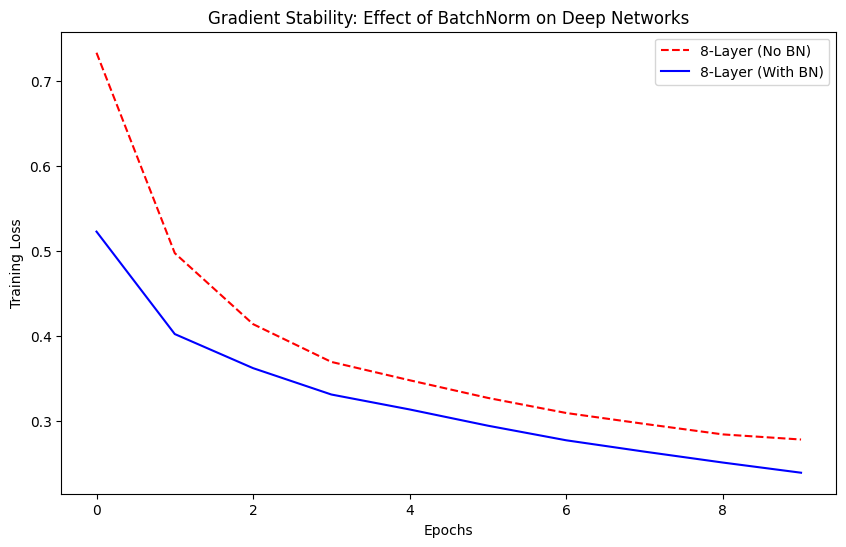

Final Accuracy (No BN): 87.99%
Final Accuracy (With BN): 88.78%


In [ ]:
#Bonus Task: Gradient Stability Investigation

# 1. Create a very deep MLP (8 hidden layers)
def make_deep_model(use_bn=False):
    layers = [nn.Flatten()]

    # Input layer to first hidden layer
    layers.append(nn.Linear(784, 256))
    if use_bn:
        layers.append(nn.BatchNorm1d(256))
    layers.append(nn.ReLU())

    # 7 more hidden layers (Total 8)
    for _ in range(7):
        layers.append(nn.Linear(256, 256))
        if use_bn:
            layers.append(nn.BatchNorm1d(256))
        layers.append(nn.ReLU())

    # Output layer
    layers.append(nn.Linear(256, 10))
    return nn.Sequential(*layers)

# 2. Train both models
print("Training Deep Model (No BN)...")
model_deep_no_bn = make_deep_model(use_bn=False).to(device)
loss_no_bn, val_no_bn = train_model(model_deep_no_bn, train_loader, test_loader)

print("\nTraining Deep Model (With BN)...")
model_deep_bn = make_deep_model(use_bn=True).to(device)
loss_bn, val_bn = train_model(model_deep_bn, train_loader, test_loader)

# 3. Compare Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(loss_no_bn, label='8-Layer (No BN)', color='red', linestyle='--')
plt.plot(loss_bn, label='8-Layer (With BN)', color='blue')
plt.title('Gradient Stability: Effect of BatchNorm on Deep Networks')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.legend()
plt.show()

# 4. Compare Final Accuracy
acc_no_bn = compute_acc(model_deep_no_bn)
acc_bn = compute_acc(model_deep_bn)

print(f"Final Accuracy (No BN): {acc_no_bn:.2f}%")
print(f"Final Accuracy (With BN): {acc_bn:.2f}%")



Bonus: Advanced Analysis Questions

1.What problem occurs in deep networks without normalization?

Deep networks without normalization often suffer from the Vanishing Gradient problem. As the gradient is backpropagated through many layers, it is repeatedly multiplied by small weights (and the derivative of the activation function). By the time the gradient reaches the initial layers, it becomes nearly zero, meaning the early layers of the network "stop learning," and the model fails to converge to a good solution.

2.How does BatchNorm help mitigate this issue?

BatchNorm ensures that the inputs to each activation function are normalized (having a mean of 0 and a variance of 1). This keeps the activations in a range where the ReLU function is "active" and prevents the values from becoming extremely large or small. By doing this, it reduces the internal covariate shift, making the network much less sensitive to the initial scale of the weights.

3.Explain the effect using the concept of gradient flow:

Gradient flow refers to the way error signals travel from the output layer back to the input layer during backpropagation. In a deep network without BN, the "flow" is often blocked or weakened because the layer outputs can shift into regions where gradients are very small (the vanishing gradient). Batch Normalization acts like a "repeater" or "stabilizer" for this flow, ensuring that the gradient maintains a healthy magnitude across all layers. This allows the weights in the very first layer to be updated as effectively as the weights in the last layer, leading to faster and more stable training.